# Participants

In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import src.stat_test_utils as stu
import src.augment_data as sad

from src.config import PATHS, palette

In [2]:
%load_ext autoreload
%autoreload 2

## Load Data

In [3]:
core_dt, task1_dt, task2_dt, task3_dt, task4_dt, task3_4_dt = sad.load_full_data(
    excl_cheaters=True,
    excl_uncertains=True,
    excl_incompl=True,
    verbose=0,
)

In [4]:
core_dt_rot = core_dt.query("var_type == 'rotational'")
core_dt_unc = core_dt.query("var_type == 'unconstrained'")

task3_dt_rot = task3_dt.query("var_type == 'rotational'")
task4_dt_rot = task4_dt.query("var_type == 'rotational'")
task3_4_dt_rot = task3_4_dt.query("var_type == 'rotational'")
task3_dt_unc = task3_dt.query("var_type == 'unconstrained'")
task4_dt_unc = task4_dt.query("var_type == 'unconstrained'")
task3_4_dt_unc = task3_4_dt.query("var_type == 'unconstrained'")

In [5]:
def describe_participants(core_dt):
    # Describe ages
    ages = core_dt["age"]#[core_dt["age"] != 'Series([], Name: response, dtype: object)'] # TODO: Remove
    ages_stats = ages.describe()
    print(f"Ages (nb {int(ages_stats["count"])}):")
    print(f" -  m ={ages_stats["mean"]:.02f}")
    print(f" - sd ={ages_stats["std"]:.02f}")
    print(f" - range ={int(ages_stats["min"])}-{int(ages_stats["max"])}")

    print("")

    # Print genders
    print(f"Gender (nb {len(core_dt["gender"])}):")
    print(" - female:", len(core_dt[core_dt["gender"]== "female"]))
    print(" - male:", len(core_dt[core_dt["gender"]== "male"]))
    print(" - other:", len(core_dt[core_dt["gender"]== "other"]))

## Times

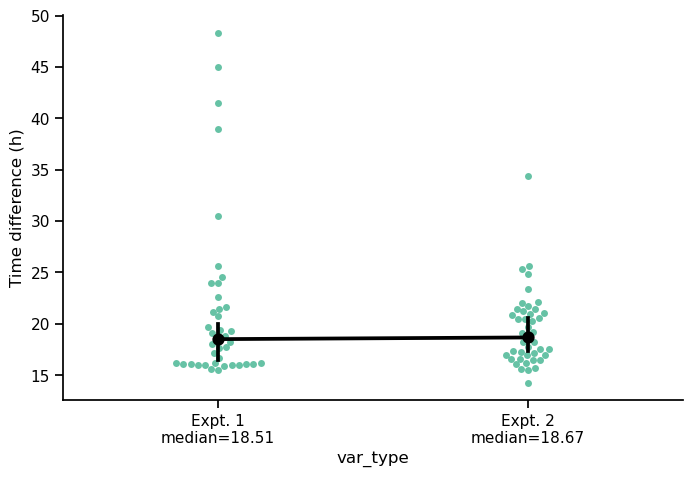

Expt. 1:  Mdn = 18.51, IQR = 16.11–21.92 (n = 40)
Expt. 2:  Mdn = 18.67, IQR = 16.94–21.12 (n = 43)


In [6]:
delta_rot = core_dt.query("var_type == 'rotational'")["time_delta_p1_p2"]
delta_unc = core_dt.query("var_type == 'unconstrained'")["time_delta_p1_p2"]

fig, axs = plt.subplots(1,1, figsize=(8,5))
sns.swarmplot(core_dt, x="var_type", y="time_delta_p1_p2", ax=axs)
sns.pointplot(core_dt, x="var_type", y="time_delta_p1_p2", estimator="median", color="black", zorder=9, ax=axs)
axs.set_ylabel("Time difference (h)")
axs.set_xticks([0, 1])
axs.set_xticklabels([f"Expt. 1\nmedian={np.median(delta_rot):.2f}", f"Expt. 2\nmedian={np.median(delta_unc):.2f}"])
plt.show()

print("Expt. 1: ", stu.report_skewed_distribution(delta_rot))
print("Expt. 2: ", stu.report_skewed_distribution(delta_unc))

## Age and Gender Statistics

In [7]:
print("Expt 1 participants")
print("-------------")
describe_participants(core_dt_rot)
print("")
print("")

print("Expt 2 participants")
print("-------------")
describe_participants(core_dt_unc)
print("")
print("")

Expt 1 participants
-------------
Ages (nb 40):
 -  m =35.62
 - sd =12.09
 - range =20-63

Gender (nb 40):
 - female: 18
 - male: 22
 - other: 0


Expt 2 participants
-------------
Ages (nb 43):
 -  m =33.70
 - sd =10.69
 - range =18-55

Gender (nb 43):
 - female: 30
 - male: 13
 - other: 0




## Times

In [8]:
print("Day 1 time: ", core_dt_rot["part1_time"].median(), "min.")
print("Day 2 time: ", core_dt_rot["part2_time"].median(), "min.")

Day 1 time:  67.15488333333333 min.
Day 2 time:  17.843049999999998 min.


In [9]:
print("Day 1 time: ", core_dt_unc["part1_time"].median(), "min.")
print("Day 2 time: ", core_dt_unc["part2_time"].median(), "min.")

Day 1 time:  67.36305 min.
Day 2 time:  14.749783333333331 min.
